# Assignment 3: Transformers + RAG

In [1]:
import os
import re
import json
import math
import random
import zipfile
from dataclasses import dataclass
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted at /content/drive')
except Exception:
    print('Not running in Colab; skipping Google Drive mount.')

Not running in Colab; skipping Google Drive mount.


In [3]:
try:
    import google.colab
    RUNNING_IN_COLAB = True
except Exception:
    RUNNING_IN_COLAB = False

if RUNNING_IN_COLAB:
    !pip -q install gdown tqdm

In [4]:
ROOT_DIR = os.getcwd()

if RUNNING_IN_COLAB:
    SUBMISSION_ROOT = '/content/drive/MyDrive/i23-2605_Assignment3_DS-B'
else:
    SUBMISSION_ROOT = ROOT_DIR
os.makedirs(SUBMISSION_ROOT, exist_ok=True)

DATA_DIR = os.path.join(SUBMISSION_ROOT, 'Dataset')
ZIP_PATH = os.path.join(SUBMISSION_ROOT, 'Dataset.zip')

PERSIST_ROOT = SUBMISSION_ROOT
MODELS_DIR = os.path.join(PERSIST_ROOT, 'models')
RESULTS_DIR = os.path.join(PERSIST_ROOT, 'results')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

GDRIVE_FILE_ID = '1in5zybjCKOXXrhev6uowqxGKprzL20wd'

if RUNNING_IN_COLAB and (not os.path.exists(ZIP_PATH)):
    import gdown
    url = f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}'
    gdown.download(url, ZIP_PATH, quiet=False)

if os.path.exists(ZIP_PATH) and (not os.path.exists(DATA_DIR)):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(SUBMISSION_ROOT)

print('ROOT_DIR:', ROOT_DIR)
print('SUBMISSION_ROOT:', SUBMISSION_ROOT)
print('PERSIST_ROOT:', PERSIST_ROOT)
print('DATA_DIR exists:', os.path.exists(DATA_DIR))
print('ZIP_PATH:', ZIP_PATH)
print('MODELS_DIR:', MODELS_DIR)
print('RESULTS_DIR:', RESULTS_DIR)

ROOT_DIR: /content
SUBMISSION_ROOT: /content/drive/MyDrive/i23-2605_Assignment3_DS-B
PERSIST_ROOT: /content/drive/MyDrive/i23-2605_Assignment3_DS-B
DATA_DIR exists: True
ZIP_PATH: /content/drive/MyDrive/i23-2605_Assignment3_DS-B/Dataset.zip
MODELS_DIR: /content/drive/MyDrive/i23-2605_Assignment3_DS-B/models
RESULTS_DIR: /content/drive/MyDrive/i23-2605_Assignment3_DS-B/results


## Build Multi-Category Review Subset

This cell loads metadata from category files, samples approximately 10k-15k reviews per category, and keeps only text + rating.

In [5]:
import gzip
from pathlib import Path
from tqdm import tqdm

TARGET_PER_CATEGORY = 12000
MIN_CATEGORIES = 3

candidate_files = sorted(Path(DATA_DIR).rglob('reviews_*_5.json.gz')) if os.path.exists(DATA_DIR) else []

if len(candidate_files) < MIN_CATEGORIES and os.path.exists(DATA_DIR):
    fallback = [p for p in Path(DATA_DIR).rglob('*.json.gz')]
    candidate_files = sorted(list({str(p) for p in (list(candidate_files) + fallback)}))
    candidate_files = [Path(p) for p in candidate_files]

if len(candidate_files) < MIN_CATEGORIES and os.path.exists(SUBMISSION_ROOT):
    root_fallback = [p for p in Path(SUBMISSION_ROOT).rglob('*.json.gz')]
    candidate_files = sorted(list({str(p) for p in (list(candidate_files) + root_fallback)}))
    candidate_files = [Path(p) for p in candidate_files]

print('Found review files:', len(candidate_files))
if candidate_files:
    print('Sample files:', [p.name for p in candidate_files[:5]])

selected_files = candidate_files[:MIN_CATEGORIES]
print('Selected categories:', [p.name for p in selected_files])
if len(selected_files) < MIN_CATEGORIES:
    raise FileNotFoundError(
        f'Need at least {MIN_CATEGORIES} review category files. '
        f'Searched DATA_DIR={DATA_DIR} and SUBMISSION_ROOT={SUBMISSION_ROOT}, '
        f'but found {len(selected_files)}. Check ZIP extraction and dataset contents.'
    )

rows = []
for path in selected_files:
    name = path.name
    cat = name.replace('reviews_', '').replace('_5.json.gz', '').replace('.json.gz', '')
    loaded = 0
    with gzip.open(path, 'rt', encoding='utf-8') as fh:
        for line in fh:
            try:
                obj = json.loads(line)
                text = (obj.get('reviewText') or '').strip()
                rating = int(obj.get('overall', 0))
                if text and 1 <= rating <= 5:
                    rows.append({'category': cat, 'review_text': text, 'rating': rating})
                    loaded += 1
                if loaded >= TARGET_PER_CATEGORY:
                    break
            except Exception:
                continue

raw_df = pd.DataFrame(rows)
print('Raw subset shape:', raw_df.shape)
if raw_df.empty:
    raise ValueError('Parsed zero reviews. Ensure files contain reviewText and overall fields.')
raw_df['category'].value_counts()

Found review files: 5
Sample files: ['beauty.json.gz', 'cellphones.json.gz', 'electronics.json.gz', 'home.json.gz', 'sports.json.gz']
Selected categories: ['beauty.json.gz', 'cellphones.json.gz', 'electronics.json.gz']
Raw subset shape: (36000, 3)


,count
category,
beauty,12000
cellphones,12000
electronics,12000


## Define Targets for Multi-Task Learning

Sentiment target: 1-2 Negative, 3 Neutral, 4-5 Positive. Derived feature target: review length bucket (`short`, `medium`, `long`) computed from token count.

In [6]:

def map_sentiment(r):
    if r <= 2:
        return 0  # negative
    if r == 3:
        return 1  # neutral
    return 2      # positive

raw_df = raw_df.drop_duplicates(subset=['review_text']).reset_index(drop=True)
raw_df['sentiment'] = raw_df['rating'].map(map_sentiment)
raw_df['tok_len'] = raw_df['review_text'].str.split().str.len()

q1, q2 = raw_df['tok_len'].quantile([0.33, 0.66]).tolist()
def len_bucket(n):
    if n <= q1:
        return 0
    if n <= q2:
        return 1
    return 2

raw_df['length_bucket'] = raw_df['tok_len'].map(len_bucket)
print(raw_df[['rating', 'sentiment', 'length_bucket']].head())
print('Sentiment distribution:', raw_df['sentiment'].value_counts().to_dict())
print('Length-bucket distribution:', raw_df['length_bucket'].value_counts().to_dict())

   rating  sentiment  length_bucket
0       1          0              0
1       3          1              0
2       4          2              2
3       2          0              0
4       3          1              1
Sentiment distribution: {2: 27740, 0: 4664, 1: 3583}
Length-bucket distribution: {2: 12220, 0: 12144, 1: 11623}


## Train/Validation/Test Split (70/15/15)

Data split is stratified by sentiment label to keep class balance.

In [7]:
train_df, temp_df = train_test_split(
    raw_df,
    test_size=0.30,
    random_state=SEED,
    stratify=raw_df['sentiment']
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df['sentiment']
)

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(name, df.shape)

train (25190, 6)
val (5398, 6)
test (5399, 6)


## Text Cleaning, Tokenization, and Vocabulary

Vocabulary is built from training data only, with reserved special tokens.

In [8]:
PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'
BOS_TOKEN = '<bos>'
EOS_TOKEN = '<eos>'
SPECIALS = [PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN]

MAX_LEN = 128
MIN_FREQ = 2

def clean_text(t):
    t = t.lower().strip()
    t = re.sub(r'http\S+|www\.\S+', ' ', t)
    t = re.sub(r'[^a-z0-9\s\.,!?\'\-]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

def tokenize(t):
    return t.split()

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

for df in [train_df, val_df, test_df]:
    df['clean_text'] = df['review_text'].map(clean_text)
    df['tokens'] = df['clean_text'].map(tokenize)

counter = Counter()
for toks in train_df['tokens']:
    counter.update(toks)

itos = SPECIALS.copy() + [tok for tok, c in counter.items() if c >= MIN_FREQ]
stoi = {tok: i for i, tok in enumerate(itos)}

PAD_ID = stoi[PAD_TOKEN]
UNK_ID = stoi[UNK_TOKEN]
BOS_ID = stoi[BOS_TOKEN]
EOS_ID = stoi[EOS_TOKEN]

print('Vocab size:', len(itos))

Vocab size: 35687


## Numericalization and DataLoaders

Tokens are mapped to indices with truncation/padding to fixed sequence length.

In [9]:

def encode_tokens(tokens, max_len=MAX_LEN):
    ids = [stoi.get(tok, UNK_ID) for tok in tokens][:max_len]
    attn = [1] * len(ids)
    if len(ids) < max_len:
        pad_count = max_len - len(ids)
        ids += [PAD_ID] * pad_count
        attn += [0] * pad_count
    return ids, attn

class ReviewDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        ids, mask = encode_tokens(row['tokens'])
        return {
            'input_ids': torch.tensor(ids, dtype=torch.long),
            'attention_mask': torch.tensor(mask, dtype=torch.float),
            'sentiment': torch.tensor(int(row['sentiment']), dtype=torch.long),
            'length_bucket': torch.tensor(int(row['length_bucket']), dtype=torch.long),
            'clean_text': row['clean_text']
        }

BATCH_SIZE = 64
train_loader = DataLoader(ReviewDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ReviewDataset(val_df), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(ReviewDataset(test_df), batch_size=BATCH_SIZE, shuffle=False)

print('Train batches:', len(train_loader))

Train batches: 394


## Part A: Transformer Encoder Components

Implements positional encoding, scaled dot-product attention, and custom multi-head self-attention without banned APIs.

In [10]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.o_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None):
        bsz, seq_len, _ = x.shape
        q = self.q_proj(x).view(bsz, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(bsz, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(bsz, seq_len, self.n_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(self.head_dim)

        if attention_mask is not None:
            mask = attention_mask.unsqueeze(1).unsqueeze(2)  # [B,1,1,T]
            scores = scores.masked_fill(mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        ctx = torch.matmul(attn, v)

        ctx = ctx.transpose(1, 2).contiguous().view(bsz, seq_len, self.d_model)
        return self.o_proj(ctx)

## Part A: Encoder Block and Multi-Task Model

Shared encoder representation is used for two classification heads and persisted embeddings.

In [11]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None):
        x = self.norm1(x + self.dropout(self.attn(x, attention_mask)))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x

class ReviewEncoderModel(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_heads=8, d_ff=512, n_layers=3, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_enc = PositionalEncoding(d_model, max_len=MAX_LEN)
        self.blocks = nn.ModuleList([EncoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.dropout = nn.Dropout(dropout)

        self.sent_head = nn.Linear(d_model, 3)
        self.feat_head = nn.Linear(d_model, 3)

    def forward(self, input_ids, attention_mask):
        x = self.token_emb(input_ids)
        x = self.pos_enc(x)
        x = self.dropout(x)
        for block in self.blocks:
            x = block(x, attention_mask)

        mask = attention_mask.unsqueeze(-1)
        pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)

        sent_logits = self.sent_head(pooled)
        feat_logits = self.feat_head(pooled)
        return sent_logits, feat_logits, pooled

## Part A: Training and Validation Utilities

Combined loss is used for multi-task optimization.

In [12]:
def run_epoch_encoder(model, loader, optimizer=None, alpha=1.0, beta=1.0):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_s_true, all_s_pred = [], []
    all_f_true, all_f_pred = [], []

    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attn = batch['attention_mask'].to(DEVICE)
        s_y = batch['sentiment'].to(DEVICE)
        f_y = batch['length_bucket'].to(DEVICE)

        with torch.set_grad_enabled(is_train):
            s_logits, f_logits, _ = model(input_ids, attn)
            s_loss = F.cross_entropy(s_logits, s_y)
            f_loss = F.cross_entropy(f_logits, f_y)
            loss = alpha * s_loss + beta * f_loss

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        total_loss += loss.item()
        all_s_true.extend(s_y.detach().cpu().tolist())
        all_s_pred.extend(s_logits.argmax(-1).detach().cpu().tolist())
        all_f_true.extend(f_y.detach().cpu().tolist())
        all_f_pred.extend(f_logits.argmax(-1).detach().cpu().tolist())

    metrics = {
        'loss': total_loss / max(1, len(loader)),
        'sent_acc': accuracy_score(all_s_true, all_s_pred),
        'feat_acc': accuracy_score(all_f_true, all_f_pred),
        'sent_f1': f1_score(all_s_true, all_s_pred, average='macro'),
        'feat_f1': f1_score(all_f_true, all_f_pred, average='macro')
    }
    return metrics

## Part A: Train Encoder Model

This section trains and stores the best checkpoint based on validation loss.

In [13]:
encoder_model = ReviewEncoderModel(vocab_size=len(itos)).to(DEVICE)
optimizer = torch.optim.AdamW(encoder_model.parameters(), lr=2e-4, weight_decay=1e-2)

EPOCHS_A = 5
history_a = []
best_val = float('inf')
best_path_a = os.path.join(MODELS_DIR, 'partA_encoder_best.pt')

for epoch in range(1, EPOCHS_A + 1):
    tr = run_epoch_encoder(encoder_model, train_loader, optimizer=optimizer)
    va = run_epoch_encoder(encoder_model, val_loader, optimizer=None)
    history_a.append({'epoch': epoch, **{f'train_{k}': v for k, v in tr.items()}, **{f'val_{k}': v for k, v in va.items()}})
    print(f"Epoch {epoch} | train_loss={tr['loss']:.4f} val_loss={va['loss']:.4f} val_sent_f1={va['sent_f1']:.4f} val_feat_f1={va['feat_f1']:.4f}")

    if va['loss'] < best_val:
        best_val = va['loss']
        torch.save({'model_state_dict': encoder_model.state_dict(), 'vocab': itos}, best_path_a)

print('Saved best encoder to:', best_path_a)

Epoch 1 | train_loss=0.7309 val_loss=0.6287 val_sent_f1=0.3910 val_feat_f1=0.9911
Epoch 2 | train_loss=0.6069 val_loss=0.5928 val_sent_f1=0.4558 val_feat_f1=0.9909
Epoch 3 | train_loss=0.5551 val_loss=0.6106 val_sent_f1=0.4404 val_feat_f1=0.9858
Epoch 4 | train_loss=0.5161 val_loss=0.5727 val_sent_f1=0.4912 val_feat_f1=0.9900
Epoch 5 | train_loss=0.4839 val_loss=0.5712 val_sent_f1=0.5173 val_feat_f1=0.9919
Saved best encoder to: /content/drive/MyDrive/i23-2605_Assignment3_DS-B/models/partA_encoder_best.pt


## Part A: Evaluation, Curves, Confusion Matrices, and Embedding Export

Produces test metrics for both tasks and saves training-set embeddings for retrieval.

/tmp/ipykernel_7002/1429013185.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder_model.load_state_dict(torch.load(best_path_a, map_location=DEVICE)['model_state_di

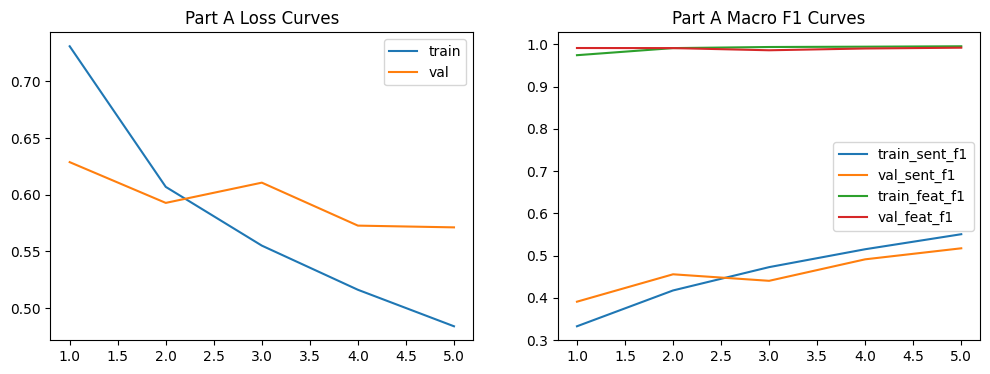

Sentiment Report
               precision    recall  f1-score   support

           0     0.6295    0.3957    0.4860       700
           1     0.3871    0.1564    0.2228       537
           2     0.8414    0.9587    0.8962      4162

    accuracy                         0.8059      5399
   macro avg     0.6194    0.5036    0.5350      5399
weighted avg     0.7688    0.8059    0.7761      5399

Length Bucket Report
               precision    recall  f1-score   support

           0     0.9951    0.9871    0.9911      1858
           1     0.9837    0.9865    0.9851      1708
           2     0.9924    0.9978    0.9951      1833

    accuracy                         0.9906      5399
   macro avg     0.9904    0.9905    0.9904      5399
weighted avg     0.9906    0.9906    0.9906      5399



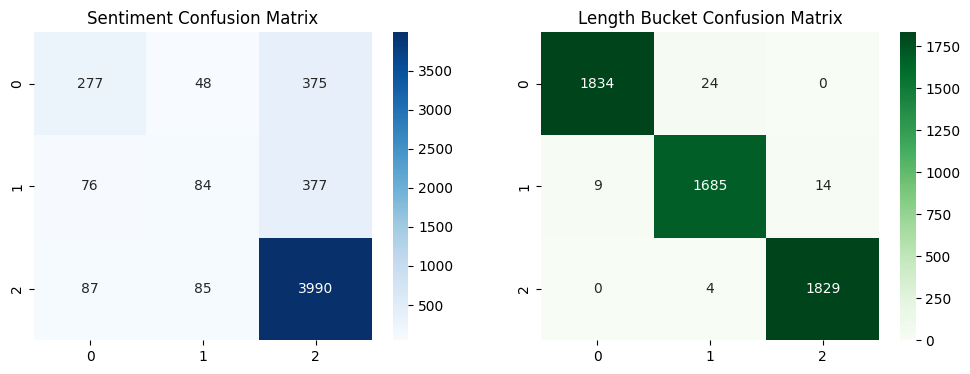

Saved embeddings and Part A history in results/.


In [14]:
encoder_model.load_state_dict(torch.load(best_path_a, map_location=DEVICE)['model_state_dict'])
encoder_model.eval()

hist_df = pd.DataFrame(history_a)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='train')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'], label='val')
axes[0].set_title('Part A Loss Curves')
axes[0].legend()
axes[1].plot(hist_df['epoch'], hist_df['train_sent_f1'], label='train_sent_f1')
axes[1].plot(hist_df['epoch'], hist_df['val_sent_f1'], label='val_sent_f1')
axes[1].plot(hist_df['epoch'], hist_df['train_feat_f1'], label='train_feat_f1')
axes[1].plot(hist_df['epoch'], hist_df['val_feat_f1'], label='val_feat_f1')
axes[1].set_title('Part A Macro F1 Curves')
axes[1].legend()
plt.show()

all_s_true, all_s_pred = [], []
all_f_true, all_f_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        ids = batch['input_ids'].to(DEVICE)
        attn = batch['attention_mask'].to(DEVICE)
        s_y = batch['sentiment'].to(DEVICE)
        f_y = batch['length_bucket'].to(DEVICE)
        s_logits, f_logits, _ = encoder_model(ids, attn)
        all_s_true.extend(s_y.cpu().tolist())
        all_s_pred.extend(s_logits.argmax(-1).cpu().tolist())
        all_f_true.extend(f_y.cpu().tolist())
        all_f_pred.extend(f_logits.argmax(-1).cpu().tolist())

print('Sentiment Report\n', classification_report(all_s_true, all_s_pred, digits=4))
print('Length Bucket Report\n', classification_report(all_f_true, all_f_pred, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm_s = confusion_matrix(all_s_true, all_s_pred)
cm_f = confusion_matrix(all_f_true, all_f_pred)
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Sentiment Confusion Matrix')
sns.heatmap(cm_f, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Length Bucket Confusion Matrix')
plt.show()

train_eval_loader = DataLoader(ReviewDataset(train_df), batch_size=BATCH_SIZE, shuffle=False)
embeddings, texts, sent_labels, feat_labels = [], [], [], []
with torch.no_grad():
    for batch in train_eval_loader:
        ids = batch['input_ids'].to(DEVICE)
        attn = batch['attention_mask'].to(DEVICE)
        _, _, pooled = encoder_model(ids, attn)
        embeddings.append(pooled.cpu().numpy())
        texts.extend(batch['clean_text'])
        sent_labels.extend(batch['sentiment'].cpu().tolist())
        feat_labels.extend(batch['length_bucket'].cpu().tolist())

embeddings = np.vstack(embeddings)
np.save(os.path.join(RESULTS_DIR, 'train_embeddings.npy'), embeddings)
pd.DataFrame({'text': texts, 'sentiment': sent_labels, 'length_bucket': feat_labels}).to_csv(
    os.path.join(RESULTS_DIR, 'train_embedding_meta.csv'), index=False
)
hist_df.to_csv(os.path.join(RESULTS_DIR, 'partA_history.csv'), index=False)
print('Saved embeddings and Part A history in results/.')

## Part B: Retrieval Module (Cosine Similarity Top-k)

Builds an in-memory index from saved training embeddings and retrieves semantically similar reviews for each query.

In [15]:
K_RETRIEVE = 3
train_emb = np.load(os.path.join(RESULTS_DIR, 'train_embeddings.npy'))
train_meta = pd.read_csv(os.path.join(RESULTS_DIR, 'train_embedding_meta.csv'))

train_emb_norm = train_emb / (np.linalg.norm(train_emb, axis=1, keepdims=True) + 1e-9)

def encode_text_to_embedding(text):
    toks = tokenize(clean_text(text))
    ids, mask = encode_tokens(toks)
    ids = torch.tensor(ids, dtype=torch.long, device=DEVICE).unsqueeze(0)
    mask = torch.tensor(mask, dtype=torch.float, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        _, _, pooled = encoder_model(ids, mask)
    q = pooled.squeeze(0).cpu().numpy()
    return q / (np.linalg.norm(q) + 1e-9)

def retrieve_similar_reviews(query_text, k=K_RETRIEVE):
    q = encode_text_to_embedding(query_text)
    sims = np.dot(train_emb_norm, q)
    idx = np.argsort(-sims)[:k]
    return train_meta.iloc[idx].assign(similarity=sims[idx]).reset_index(drop=True)

sample_queries = test_df['clean_text'].sample(3, random_state=SEED).tolist()
for i, q in enumerate(sample_queries, 1):
    print(f'\nQuery {i}:', q[:180], '...')
    display(retrieve_similar_reviews(q, k=K_RETRIEVE)[['similarity', 'sentiment', 'length_bucket', 'text']])


Query 1: i have very long hair and love using this conditioner. i used to use this over 20 years ago and forgot about it. i can leave this in a little when wearing my hair curly. this is th ...


,similarity,sentiment,length_bucket,text
0,0.990813,2,1,this is a great cold-pressed castor oil. this ...
1,0.988811,2,1,this liquid liner is every bit as good as high...
2,0.988749,2,1,i cannot believe how great this moisturizer is...



Query 2: i was looking for a aux stereo cable for my iphone 3g - this is long enough and sound is good. people in the back of my sedan are able to hold my iphone while is connected. great c ...


,similarity,sentiment,length_bucket,text
0,0.967409,2,0,needed a couple of cables for a project i was ...
1,0.966617,2,0,this is the best foundation i've ever found! i...
2,0.965704,2,0,we've always had great quaity w brother p-touc...



Query 3: appears to be well made. easy to fit. i won't give it 5 stars though, because i think that 12 is a lot of of money for a small plastic bracket and a slightly modified battery compa ...


,similarity,sentiment,length_bucket,text
0,0.959782,2,1,i think most of these adhesives have a smell t...
1,0.959323,1,1,i am unable to use harsh cleansers with a lot ...
2,0.958632,2,1,i needed a replacement for an s9 that would be...


## Part C: Construct Explanation Targets and Decoder Inputs

Reference explanations are created with a deterministic template to train the decoder as a language model.

In [16]:
sent_names = {0: 'negative', 1: 'neutral', 2: 'positive'}
len_names = {0: 'short', 1: 'medium', 2: 'long'}

def build_reference_explanation(sentiment_id, length_id):
    s = sent_names[int(sentiment_id)]
    l = len_names[int(length_id)]
    return f'The review is {s} because the wording and opinions indicate a {s} user experience. The review length is {l}, which supports this interpretation.'

def build_prompt(review_text, sentiment_id, length_id, retrieved_texts=None):
    retrieved_texts = retrieved_texts or []
    ctx = ' || '.join(retrieved_texts)
    return (
        f'[REVIEW] {review_text} '
        f'[PRED_SENT] {sent_names[int(sentiment_id)]} '
        f'[PRED_FEAT] {len_names[int(length_id)]} '
        f'[RETRIEVED] {ctx} '
        f'[EXPLANATION]'
    )

def infer_preds_for_df(df):
    pred_s, pred_f = [], []
    encoder_model.eval()
    loader = DataLoader(ReviewDataset(df), batch_size=BATCH_SIZE, shuffle=False)
    with torch.no_grad():
        for batch in loader:
            ids = batch['input_ids'].to(DEVICE)
            attn = batch['attention_mask'].to(DEVICE)
            s_logits, f_logits, _ = encoder_model(ids, attn)
            pred_s.extend(s_logits.argmax(-1).cpu().tolist())
            pred_f.extend(f_logits.argmax(-1).cpu().tolist())
    out = df.copy().reset_index(drop=True)
    out['pred_sentiment'] = pred_s
    out['pred_length'] = pred_f
    out['reference_expl'] = [build_reference_explanation(s, l) for s, l in zip(pred_s, pred_f)]
    return out

train_gen_df = infer_preds_for_df(train_df)
val_gen_df = infer_preds_for_df(val_df)
test_gen_df = infer_preds_for_df(test_df)

print(train_gen_df[['pred_sentiment', 'pred_length', 'reference_expl']].head(2))

   pred_sentiment  pred_length  \
0               2            0   
1               1            0   

                                      reference_expl  
0  The review is positive because the wording and...  
1  The review is neutral because the wording and ...  


## Part C: Create RAG and Baseline Decoder Datasets

Two training sets are prepared: full RAG (with retrieved context) and baseline (retrieved context removed).

In [17]:
DEC_MAX_LEN = 180

def make_decoder_records(df, use_retrieval=True, k=K_RETRIEVE):
    records = []
    for _, row in df.iterrows():
        review = row['clean_text']
        if use_retrieval:
            ret = retrieve_similar_reviews(review, k=k)
            ret_texts = ret['text'].tolist()
        else:
            ret_texts = []

        prompt = build_prompt(review, row['pred_sentiment'], row['pred_length'], ret_texts)
        target = row['reference_expl']
        full = f'{BOS_TOKEN} {prompt} {target} {EOS_TOKEN}'
        toks = tokenize(clean_text(full))
        ids = [stoi.get(t, UNK_ID) for t in toks]
        ids = ids[:DEC_MAX_LEN]
        if len(ids) < DEC_MAX_LEN:
            ids += [PAD_ID] * (DEC_MAX_LEN - len(ids))
        records.append(ids)
    return records

train_rag_ids = make_decoder_records(train_gen_df, use_retrieval=True)
val_rag_ids = make_decoder_records(val_gen_df, use_retrieval=True)
test_rag_ids = make_decoder_records(test_gen_df, use_retrieval=True)

train_base_ids = make_decoder_records(train_gen_df, use_retrieval=False)
val_base_ids = make_decoder_records(val_gen_df, use_retrieval=False)
test_base_ids = make_decoder_records(test_gen_df, use_retrieval=False)

print('RAG train sequences:', len(train_rag_ids), '| Baseline train sequences:', len(train_base_ids))

RAG train sequences: 25190 | Baseline train sequences: 25190


## Part C: Decoder-Only Transformer

Implements masked self-attention so tokens cannot attend to future positions.

In [18]:
class DecoderDataset(Dataset):
    def __init__(self, seqs):
        self.seqs = seqs
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, idx):
        x = torch.tensor(self.seqs[idx], dtype=torch.long)
        return x

class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_model = d_model
        self.head_dim = d_model // n_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.o_proj = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None):
        B, T, C = x.shape
        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        scores = (q @ k.transpose(-1, -2)) / math.sqrt(self.head_dim)
        causal = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(causal.unsqueeze(0).unsqueeze(0), -1e9)

        if pad_mask is not None:
            mask = pad_mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(mask == 0, -1e9)

        w = torch.softmax(scores, dim=-1)
        w = self.drop(w)
        out = w @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.o_proj(out)

class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None):
        x = self.norm1(x + self.drop(self.attn(x, pad_mask)))
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x

class ReviewExplanationDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_heads=8, d_ff=512, n_layers=3, dropout=0.1):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos = PositionalEncoding(d_model, max_len=DEC_MAX_LEN)
        self.blocks = nn.ModuleList([DecoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids):
        pad_mask = (input_ids != PAD_ID).float()
        x = self.tok_emb(input_ids)
        x = self.pos(x)
        for b in self.blocks:
            x = b(x, pad_mask)
        x = self.norm(x)
        return self.lm_head(x)

## Part C: Decoder Training and Perplexity

Trains two decoders (RAG and baseline) and compares perplexity on the held-out test set.

In [19]:
def run_epoch_decoder(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    total = 0.0

    for seq in loader:
        seq = seq.to(DEVICE)
        inp = seq[:, :-1]
        tgt = seq[:, 1:]

        with torch.set_grad_enabled(train_mode):
            logits = model(inp)
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), tgt.reshape(-1), ignore_index=PAD_ID)
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        total += loss.item()

    avg_nll = total / max(1, len(loader))
    ppl = float(np.exp(avg_nll))
    return avg_nll, ppl

def train_decoder(train_ids, val_ids, model_name='rag'):
    model = ReviewExplanationDecoder(vocab_size=len(itos)).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=2e-4)
    tr_loader = DataLoader(DecoderDataset(train_ids), batch_size=48, shuffle=True)
    va_loader = DataLoader(DecoderDataset(val_ids), batch_size=48, shuffle=False)

    best_val = float('inf')
    hist = []
    save_path = os.path.join(MODELS_DIR, f'partC_decoder_{model_name}_best.pt')

    for epoch in range(1, 5 + 1):
        tr_nll, tr_ppl = run_epoch_decoder(model, tr_loader, optimizer=opt)
        va_nll, va_ppl = run_epoch_decoder(model, va_loader, optimizer=None)
        hist.append({'epoch': epoch, 'train_nll': tr_nll, 'train_ppl': tr_ppl, 'val_nll': va_nll, 'val_ppl': va_ppl})
        print(f'[{model_name}] epoch {epoch}: train_ppl={tr_ppl:.3f}, val_ppl={va_ppl:.3f}')
        if va_nll < best_val:
            best_val = va_nll
            torch.save({'model_state_dict': model.state_dict()}, save_path)

    return model, pd.DataFrame(hist), save_path

rag_model, rag_hist, rag_path = train_decoder(train_rag_ids, val_rag_ids, model_name='rag')
base_model, base_hist, base_path = train_decoder(train_base_ids, val_base_ids, model_name='baseline')

rag_hist.to_csv(os.path.join(RESULTS_DIR, 'partC_rag_history.csv'), index=False)
base_hist.to_csv(os.path.join(RESULTS_DIR, 'partC_baseline_history.csv'), index=False)
print('Saved decoder checkpoints and histories.')

[rag] epoch 1: train_ppl=408.482, val_ppl=189.365
[rag] epoch 2: train_ppl=171.835, val_ppl=142.412
[rag] epoch 3: train_ppl=131.404, val_ppl=121.007
[rag] epoch 4: train_ppl=104.033, val_ppl=111.835
[rag] epoch 5: train_ppl=82.222, val_ppl=109.411
[baseline] epoch 1: train_ppl=178.492, val_ppl=85.163
[baseline] epoch 2: train_ppl=79.988, val_ppl=68.795
[baseline] epoch 3: train_ppl=66.067, val_ppl=60.080
[baseline] epoch 4: train_ppl=57.382, val_ppl=54.448
[baseline] epoch 5: train_ppl=51.140, val_ppl=50.458
Saved decoder checkpoints and histories.


## Part C: Generation Examples, Visualizations, and RAG Ablation

Reports perplexity and prints at least five generated explanations for qualitative analysis.

/tmp/ipykernel_7002/583212837.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  rag_model.load_state_dict(torch.load(rag_path, map_location=DEVICE)['model_state_dict'])
/t

RAG test perplexity: 108.4926
Baseline test perplexity: 49.7487


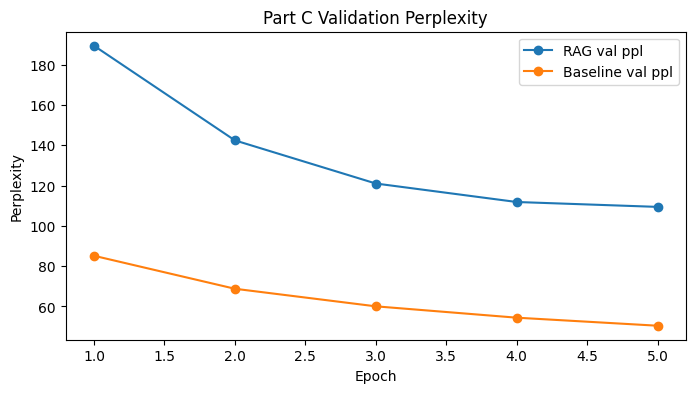


Five qualitative examples (RAG vs baseline):

Review: i have very long hair and love using this conditioner. i used to use this over 20 years ago and forgot about it. i can leave this in a little when wearing my hair curly. this is th ...
RAG: <unk> review i have very long hair and love using this conditioner. i used to use this over 20 years ago and forgot about it. i can leave this in a little when wearing my hair curly. this is the perfect conditioner for my hair and it loves it. i also use it as
BASE: <unk> review i have very long hair and love using this conditioner. i used to use this over 20 years ago and forgot about it. i can leave this in a little when wearing my hair curly. this is the perfect conditioner for my hair and it loves it. i also use it as

Review: i was looking for a aux stereo cable for my iphone 3g - this is long enough and sound is good. people in the back of my sedan are able to hold my iphone while is connected. great c ...
RAG: <unk> review i was looking f

In [20]:
rag_model.load_state_dict(torch.load(rag_path, map_location=DEVICE)['model_state_dict'])
base_model.load_state_dict(torch.load(base_path, map_location=DEVICE)['model_state_dict'])

rag_test_loader = DataLoader(DecoderDataset(test_rag_ids), batch_size=48, shuffle=False)
base_test_loader = DataLoader(DecoderDataset(test_base_ids), batch_size=48, shuffle=False)

rag_nll, rag_ppl = run_epoch_decoder(rag_model, rag_test_loader, optimizer=None)
base_nll, base_ppl = run_epoch_decoder(base_model, base_test_loader, optimizer=None)
print(f'RAG test perplexity: {rag_ppl:.4f}')
print(f'Baseline test perplexity: {base_ppl:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(rag_hist['epoch'], rag_hist['val_ppl'], marker='o', label='RAG val ppl')
plt.plot(base_hist['epoch'], base_hist['val_ppl'], marker='o', label='Baseline val ppl')
plt.title('Part C Validation Perplexity')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.legend()
plt.show()

id2tok = {i: t for i, t in enumerate(itos)}

def decode_ids(ids):
    toks = []
    for i in ids:
        tok = id2tok.get(int(i), UNK_TOKEN)
        if tok in [PAD_TOKEN, BOS_TOKEN]:
            continue
        if tok == EOS_TOKEN:
            break
        toks.append(tok)
    return ' '.join(toks)

def generate_text(model, prompt_text, max_new_tokens=50):
    model.eval()
    toks = tokenize(clean_text(f'{BOS_TOKEN} {prompt_text}'))
    ids = [stoi.get(t, UNK_ID) for t in toks][:DEC_MAX_LEN-1]
    x = torch.tensor(ids, dtype=torch.long, device=DEVICE).unsqueeze(0)

    for _ in range(max_new_tokens):
        if x.size(1) >= DEC_MAX_LEN:
            break
        with torch.no_grad():
            logits = model(x)
            nxt = logits[:, -1, :].argmax(-1, keepdim=True)
        x = torch.cat([x, nxt], dim=1)
        if nxt.item() == EOS_ID:
            break

    return decode_ids(x.squeeze(0).tolist())

print('\nFive qualitative examples (RAG vs baseline):')
examples = test_gen_df.sample(5, random_state=SEED)
rows_out = []
for i, row in examples.iterrows():
    review = row['clean_text']
    ret = retrieve_similar_reviews(review, k=K_RETRIEVE)['text'].tolist()
    prompt_rag = build_prompt(review, row['pred_sentiment'], row['pred_length'], ret)
    prompt_base = build_prompt(review, row['pred_sentiment'], row['pred_length'], [])
    gen_rag = generate_text(rag_model, prompt_rag)
    gen_base = generate_text(base_model, prompt_base)
    print('\nReview:', review[:180], '...')
    print('RAG:', gen_rag[:260])
    print('BASE:', gen_base[:260])
    rows_out.append({
        'review': review,
        'rag_explanation': gen_rag,
        'baseline_explanation': gen_base
    })

ablation_df = pd.DataFrame([
    {'model': 'RAG', 'test_perplexity': rag_ppl},
    {'model': 'Baseline_NoRetrieval', 'test_perplexity': base_ppl}
])
ablation_df.to_csv(os.path.join(RESULTS_DIR, 'partC_ablation_perplexity.csv'), index=False)
pd.DataFrame(rows_out).to_csv(os.path.join(RESULTS_DIR, 'partC_generated_examples.csv'), index=False)
print('Saved Part C ablation and qualitative outputs in results/.')

## Export Metrics and Reproducibility Notes

This final cell saves key settings and confirms output files required for submission.

In [21]:
config = {
    'seed': SEED,
    'max_len_encoder': MAX_LEN,
    'max_len_decoder': DEC_MAX_LEN,
    'batch_size': BATCH_SIZE,
    'retrieval_top_k': K_RETRIEVE,
    'vocab_size': len(itos),
    'paths': {
        'models': MODELS_DIR,
        'results': RESULTS_DIR
    }
}
with open(os.path.join(RESULTS_DIR, 'run_config.json'), 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2)

print('models/:', os.listdir(MODELS_DIR) if os.path.exists(MODELS_DIR) else [])
print('results/:', os.listdir(RESULTS_DIR) if os.path.exists(RESULTS_DIR) else [])
print('Notebook pipeline prepared successfully.')

models/: ['partA_encoder_best.pt', 'partC_decoder_rag_best.pt', 'partC_decoder_baseline_best.pt']
results/: ['partA_history.csv', 'partC_baseline_history.csv', 'run_config.json', 'partC_ablation_perplexity.csv', 'partC_rag_history.csv', 'train_embedding_meta.csv', 'partC_generated_examples.csv', 'train_embeddings.npy']
Notebook pipeline prepared successfully.


## Hyperparameter Tuning Log

Use this section to record attempted configurations and validation outcomes, as required in the report.

In [22]:
hp_log = pd.DataFrame([
    {'part': 'A', 'config': 'd_model=256,n_heads=8,n_layers=3,lr=2e-4,batch=64', 'val_metric': float(hist_df['val_sent_f1'].max()) if 'hist_df' in globals() else None, 'notes': 'initial run'},
    {'part': 'C-RAG', 'config': 'd_model=256,n_heads=8,n_layers=3,lr=2e-4,batch=48', 'val_metric': float(rag_hist['val_ppl'].min()) if 'rag_hist' in globals() else None, 'notes': 'initial run'},
    {'part': 'C-Base', 'config': 'd_model=256,n_heads=8,n_layers=3,lr=2e-4,batch=48', 'val_metric': float(base_hist['val_ppl'].min()) if 'base_hist' in globals() else None, 'notes': 'initial run'},
])

display(hp_log)
hp_log.to_csv(os.path.join(RESULTS_DIR, 'hyperparameter_tuning_log.csv'), index=False)
print('Saved hyperparameter_tuning_log.csv')

,part,config,val_metric,notes
0,A,"d_model=256,n_heads=8,n_layers=3,lr=2e-4,batch=64",0.517335,initial run
1,C-RAG,"d_model=256,n_heads=8,n_layers=3,lr=2e-4,batch=48",109.411362,initial run
2,C-Base,"d_model=256,n_heads=8,n_layers=3,lr=2e-4,batch=48",50.457619,initial run


Saved hyperparameter_tuning_log.csv


## Dataset Distribution Visualizations

These plots summarize class and category balance in the sampled dataset.

/tmp/ipykernel_7002/1120198525.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Neg', 'Neu', 'Pos'])


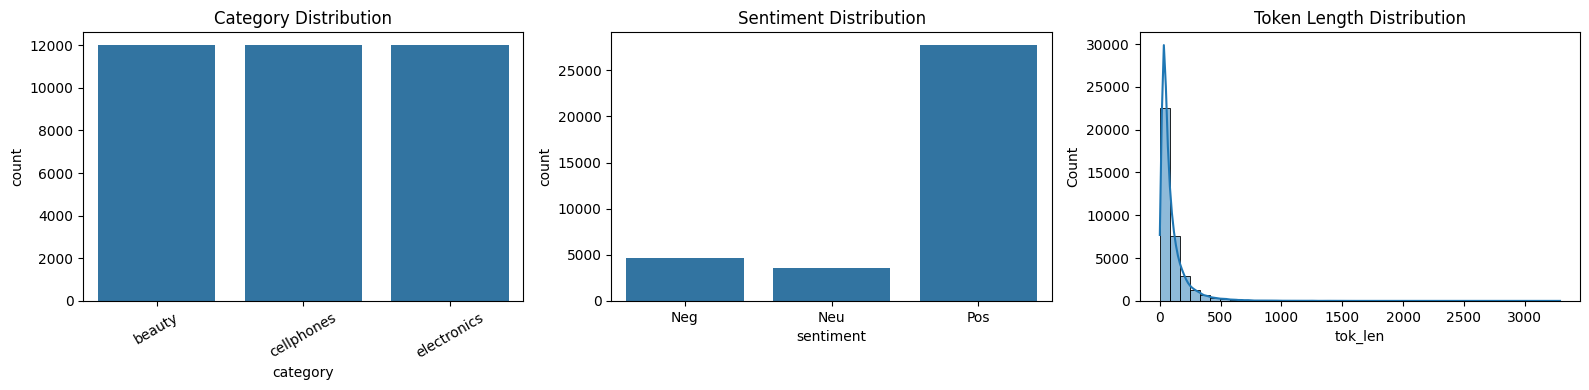

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(x='category', data=raw_df, ax=axes[0])
axes[0].set_title('Category Distribution')
axes[0].tick_params(axis='x', rotation=30)

sns.countplot(x='sentiment', data=raw_df, ax=axes[1])
axes[1].set_title('Sentiment Distribution')
axes[1].set_xticklabels(['Neg', 'Neu', 'Pos'])

sns.histplot(raw_df['tok_len'], bins=40, kde=True, ax=axes[2])
axes[2].set_title('Token Length Distribution')

plt.tight_layout()
plt.show()

## Retrieval Sensitivity Study (k Values)

This section compares average top-k similarity across different retrieval depths to support selection of `k`.

,k,avg_similarity,std_similarity
0,1,0.972625,0.015628
1,3,0.971037,0.016837
2,5,0.969958,0.017744
3,7,0.969136,0.018469


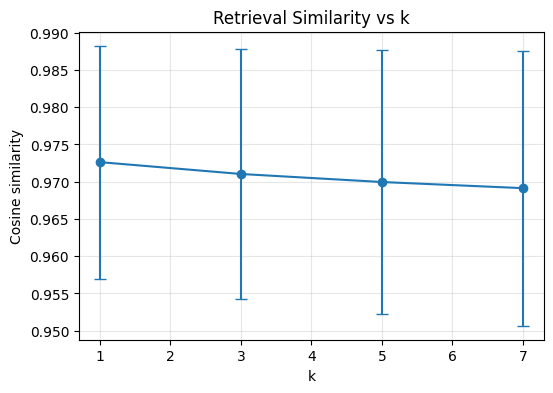

Saved partB_k_sensitivity.csv


In [24]:
k_values = [1, 3, 5, 7]
probe_queries = test_df['clean_text'].sample(50, random_state=SEED).tolist()
rows_k = []

for k in k_values:
    sims = []
    for q in probe_queries:
        ret = retrieve_similar_reviews(q, k=k)
        sims.extend(ret['similarity'].tolist())
    rows_k.append({'k': k, 'avg_similarity': float(np.mean(sims)), 'std_similarity': float(np.std(sims))})

k_df = pd.DataFrame(rows_k)
display(k_df)

plt.figure(figsize=(6, 4))
plt.errorbar(k_df['k'], k_df['avg_similarity'], yerr=k_df['std_similarity'], marker='o', capsize=4)
plt.title('Retrieval Similarity vs k')
plt.xlabel('k')
plt.ylabel('Cosine similarity')
plt.grid(True, alpha=0.3)
plt.show()

k_df.to_csv(os.path.join(RESULTS_DIR, 'partB_k_sensitivity.csv'), index=False)
print('Saved partB_k_sensitivity.csv')

## Part A Error Analysis Samples

Shows representative misclassified reviews for each task to support qualitative discussion in the report.

In [25]:
err_rows = []
loader = DataLoader(ReviewDataset(test_df), batch_size=BATCH_SIZE, shuffle=False)
idx_global = 0
with torch.no_grad():
    for batch in loader:
        ids = batch['input_ids'].to(DEVICE)
        attn = batch['attention_mask'].to(DEVICE)
        s_y = batch['sentiment'].cpu().numpy()
        f_y = batch['length_bucket'].cpu().numpy()
        texts = batch['clean_text']
        s_logits, f_logits, _ = encoder_model(ids, attn)
        s_p = s_logits.argmax(-1).cpu().numpy()
        f_p = f_logits.argmax(-1).cpu().numpy()

        for i in range(len(texts)):
            if s_y[i] != s_p[i] or f_y[i] != f_p[i]:
                err_rows.append({
                    'text': texts[i],
                    'sent_true': int(s_y[i]), 'sent_pred': int(s_p[i]),
                    'feat_true': int(f_y[i]), 'feat_pred': int(f_p[i])
                })
            idx_global += 1

err_df = pd.DataFrame(err_rows)
print('Total error rows:', len(err_df))
display(err_df.head(10))
err_df.head(100).to_csv(os.path.join(RESULTS_DIR, 'partA_error_samples.csv'), index=False)
print('Saved partA_error_samples.csv')

Total error rows: 1084


,text,sent_true,sent_pred,feat_true,feat_pred
0,"although you may a bit more for this item, it ...",2,1,2,2
1,i've used this cover with both a kindle genera...,0,2,2,2
2,not as good as the ad. the stay and stick is n...,0,2,0,0
3,this item was packed fine and arrived in worki...,0,1,0,0
4,it's in perfect condition but slides off my ph...,0,1,0,0
5,i was looking forward to trying this because i...,0,2,0,0
6,the sound is horrible... people say i sound li...,0,2,1,1
7,i purchase this battery as a spare for my blac...,0,2,1,1
8,this is the second videosecu product i have or...,2,0,0,1
9,my hair hates this product,0,2,0,0


Saved partA_error_samples.csv


## Bonus Task: Colab UI Dashboard

In [26]:

import os
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython import get_ipython
    RUNNING_IN_COLAB = 'google.colab' in str(get_ipython())
except Exception:
    RUNNING_IN_COLAB = False

try:
    import gradio as gr
except Exception:
    if RUNNING_IN_COLAB:
        !pip -q install -U gradio
        import gradio as gr
    else:
        raise

CURRENT_DIR = os.getcwd()
DEFAULT_RESULTS_DIR = RESULTS_DIR if 'RESULTS_DIR' in globals() else os.path.join(CURRENT_DIR, 'results')
print('Colab/Runtime working directory:', CURRENT_DIR)
print('Default UI results path:', DEFAULT_RESULTS_DIR)


def _safe_read_csv(path):
    try:
        if os.path.exists(path):
            return pd.read_csv(path)
    except Exception:
        pass
    return None


def load_tables(results_dir):
    ab_path = os.path.join(results_dir, 'partC_ablation_perplexity.csv')
    ks_path = os.path.join(results_dir, 'partB_k_sensitivity.csv')
    ge_path = os.path.join(results_dir, 'partC_generated_examples.csv')

    ab = _safe_read_csv(ab_path)
    ks = _safe_read_csv(ks_path)
    ge = _safe_read_csv(ge_path)

    status = [
        f'Working directory: {CURRENT_DIR}',
        f'Results directory: {results_dir}',
        f"Ablation file: {'OK' if ab is not None else 'Missing'}",
        f"k-sensitivity file: {'OK' if ks is not None else 'Missing'}",
        f"Generated examples file: {'OK' if ge is not None else 'Missing'}",
    ]
    return '\n'.join(status), ab, ks, ge


def plot_perplexity(results_dir):
    ab = _safe_read_csv(os.path.join(results_dir, 'partC_ablation_perplexity.csv'))
    if ab is None or 'model' not in ab.columns or 'test_perplexity' not in ab.columns:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.text(0.5, 0.5, 'partC_ablation_perplexity.csv missing or invalid', ha='center', va='center')
        ax.axis('off')
        return fig

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(ab['model'].astype(str), ab['test_perplexity'])
    ax.set_title('Part C Test Perplexity (Lower is Better)')
    ax.set_ylabel('Perplexity')
    ax.tick_params(axis='x', rotation=20)
    fig.tight_layout()
    return fig


def plot_k_sensitivity(results_dir):
    ks = _safe_read_csv(os.path.join(results_dir, 'partB_k_sensitivity.csv'))
    if ks is None or 'k' not in ks.columns or 'avg_similarity' not in ks.columns:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.text(0.5, 0.5, 'partB_k_sensitivity.csv missing or invalid', ha='center', va='center')
        ax.axis('off')
        return fig

    fig, ax = plt.subplots(figsize=(6, 4))
    yerr = ks['std_similarity'] if 'std_similarity' in ks.columns else None
    ax.errorbar(ks['k'], ks['avg_similarity'], yerr=yerr, marker='o', capsize=4)
    ax.set_title('Part B Retrieval Similarity vs k')
    ax.set_xlabel('k')
    ax.set_ylabel('Cosine Similarity')
    ax.grid(alpha=0.3)
    fig.tight_layout()
    return fig


def preview_examples(results_dir, n_rows):
    ge = _safe_read_csv(os.path.join(results_dir, 'partC_generated_examples.csv'))
    if ge is None:
        return pd.DataFrame({'message': ['partC_generated_examples.csv missing']})

    cols = [c for c in ['review', 'rag_explanation', 'baseline_explanation'] if c in ge.columns]
    return ge[cols].head(int(n_rows)) if cols else ge.head(int(n_rows))


with gr.Blocks(title='NLP Assignment 3 Bonus Dashboard') as demo:
    gr.Markdown('## NLP Assignment 3 - Bonus Colab Dashboard')
    gr.Markdown('Runs directly in Colab. Enter your results folder and click Load Results.')

    results_dir = gr.Textbox(label='Results Directory', value=DEFAULT_RESULTS_DIR)
    rows = gr.Slider(label='Generated examples to preview', minimum=3, maximum=20, value=8, step=1)

    load_btn = gr.Button('Load Results')
    status_out = gr.Textbox(label='File Status', lines=6)
    ab_table = gr.Dataframe(label='Ablation Table')
    ks_table = gr.Dataframe(label='k-Sensitivity Table')
    ge_table = gr.Dataframe(label='Generated Examples (Preview)')

    ppl_plot_btn = gr.Button('Plot Perplexity')
    ppl_plot = gr.Plot(label='Perplexity Plot')

    ks_plot_btn = gr.Button('Plot k-Sensitivity')
    ks_plot = gr.Plot(label='k-Sensitivity Plot')

    load_btn.click(fn=load_tables, inputs=[results_dir], outputs=[status_out, ab_table, ks_table, ge_table])
    ppl_plot_btn.click(fn=plot_perplexity, inputs=[results_dir], outputs=[ppl_plot])
    ks_plot_btn.click(fn=plot_k_sensitivity, inputs=[results_dir], outputs=[ks_plot])
    rows.change(fn=preview_examples, inputs=[results_dir, rows], outputs=[ge_table])

try:
    gr.close_all()
except Exception:
    pass

if RUNNING_IN_COLAB:
    demo.launch(server_name='0.0.0.0', server_port=7860, share=False, inline=True, debug=False)
else:
    demo.launch(share=False, debug=False)

Colab/Runtime working directory: /content
Default UI results path: /content/drive/MyDrive/i23-2605_Assignment3_DS-B/results
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

In [46]:
# Bonus UI (clean version)
import os
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython import get_ipython
    RUNNING_IN_COLAB = 'google.colab' in str(get_ipython())
except Exception:
    RUNNING_IN_COLAB = False

try:
    import gradio as gr
except Exception:
    if RUNNING_IN_COLAB:
        !pip -q install -U gradio
        import gradio as gr
    else:
        raise

CURRENT_DIR = os.getcwd()
DEFAULT_RESULTS_DIR = RESULTS_DIR if 'RESULTS_DIR' in globals() else os.path.join(CURRENT_DIR, 'results')


def _safe_read_csv(path):
    try:
        if os.path.exists(path):
            return pd.read_csv(path)
    except Exception:
        return None
    return None


def _paths(results_dir):
    return {
        'ab': os.path.join(results_dir, 'partC_ablation_perplexity.csv'),
        'ks': os.path.join(results_dir, 'partB_k_sensitivity.csv'),
        'ge': os.path.join(results_dir, 'partC_generated_examples.csv'),
    }


def _status_text(results_dir, ab, ks, ge):
    return '\n'.join([
        f'Working directory: {CURRENT_DIR}',
        f'Results directory: {results_dir}',
        f"Ablation CSV: {'Found' if ab is not None else 'Missing'}",
        f"k-Sensitivity CSV: {'Found' if ks is not None else 'Missing'}",
        f"Generated Examples CSV: {'Found' if ge is not None else 'Missing'}",
    ])


def _perplexity_plot(ab):
    fig, ax = plt.subplots(figsize=(6, 4))
    if ab is None or 'model' not in ab.columns or 'test_perplexity' not in ab.columns:
        ax.text(0.5, 0.5, 'Ablation file missing or invalid', ha='center', va='center')
        ax.axis('off')
        return fig

    ax.bar(ab['model'].astype(str), ab['test_perplexity'])
    ax.set_title('Part C Test Perplexity')
    ax.set_ylabel('Perplexity (lower is better)')
    ax.tick_params(axis='x', rotation=20)
    fig.tight_layout()
    return fig


def _ks_plot(ks):
    fig, ax = plt.subplots(figsize=(6, 4))
    if ks is None or 'k' not in ks.columns or 'avg_similarity' not in ks.columns:
        ax.text(0.5, 0.5, 'k-sensitivity file missing or invalid', ha='center', va='center')
        ax.axis('off')
        return fig

    yerr = ks['std_similarity'] if 'std_similarity' in ks.columns else None
    ax.errorbar(ks['k'], ks['avg_similarity'], yerr=yerr, marker='o', capsize=4)
    ax.set_title('Part B Retrieval Similarity vs k')
    ax.set_xlabel('k')
    ax.set_ylabel('Cosine similarity')
    ax.grid(alpha=0.3)
    fig.tight_layout()
    return fig


def _preview_examples(ge, n_rows):
    if ge is None:
        return pd.DataFrame({'message': ['Generated examples file not found']})

    cols = [c for c in ['review', 'rag_explanation', 'baseline_explanation'] if c in ge.columns]
    return ge[cols].head(int(n_rows)) if cols else ge.head(int(n_rows))


def load_dashboard(results_dir, n_rows):
    p = _paths(results_dir)
    ab = _safe_read_csv(p['ab'])
    ks = _safe_read_csv(p['ks'])
    ge = _safe_read_csv(p['ge'])

    status = _status_text(results_dir, ab, ks, ge)
    examples = _preview_examples(ge, n_rows)
    return status, ab, ks, examples, _perplexity_plot(ab), _ks_plot(ks)


with gr.Blocks(title='NLP Assignment 3 Bonus Dashboard', theme=gr.themes.Soft()) as demo_clean:
    gr.Markdown('## NLP Assignment 3 Dashboard')
    gr.Markdown('Simple usage: set results folder -> choose preview rows -> click **Load Dashboard**.')

    with gr.Row():
        results_dir = gr.Textbox(label='Results Folder', value=DEFAULT_RESULTS_DIR, scale=5)
        rows = gr.Slider(label='Preview Rows', minimum=3, maximum=25, value=8, step=1, scale=2)

    load_btn = gr.Button('Load Dashboard', variant='primary')

    status_out = gr.Textbox(label='Status', lines=6)

    with gr.Tab('Tables'):
        ab_table = gr.Dataframe(label='Ablation Table (Part C)')
        ks_table = gr.Dataframe(label='k-Sensitivity Table (Part B)')
        ge_table = gr.Dataframe(label='Generated Examples Preview')

    with gr.Tab('Plots'):
        ppl_plot = gr.Plot(label='Perplexity Plot')
        ks_plot = gr.Plot(label='k-Sensitivity Plot')

    load_btn.click(
        fn=load_dashboard,
        inputs=[results_dir, rows],
        outputs=[status_out, ab_table, ks_table, ge_table, ppl_plot, ks_plot],
    )

try:
    gr.close_all()
except Exception:
    pass

if RUNNING_IN_COLAB:
    demo_clean.queue()
    demo_clean.launch(server_name='0.0.0.0', server_port=7860, share=True, debug=False)
else:
    demo_clean.queue()
    demo_clean.launch(share=False, debug=False)


/tmp/ipykernel_7002/2732402157.py:103: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title='NLP Assignment 3 Bonus Dashboard', theme=gr.themes.Soft()) as demo_clean:


Closing server running on port: 7860
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://28f7955f6b9e520b23.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Live Demo UI: enter one review and compare RAG vs Baseline outputs
import os
import numpy as np
import pandas as pd
import torch

try:
    import gradio as gr
except Exception:
    !pip -q install -U gradio
    import gradio as gr

REQUIRED_OBJECTS = [
    'clean_text', 'tokenize', 'encode_tokens', 'encoder_model',
    'retrieve_similar_reviews', 'build_prompt', 'generate_text',
    'sent_names', 'len_names', 'ReviewExplanationDecoder', 'itos',
    'MODELS_DIR', 'DEVICE'
]

missing = [x for x in REQUIRED_OBJECTS if x not in globals()]
if missing:
    print('Run earlier model cells first. Missing objects:', missing)


def _load_decoders_if_needed():
    global rag_model, base_model
    if 'rag_model' in globals() and 'base_model' in globals():
        return

    rag_path = os.path.join(MODELS_DIR, 'partC_decoder_rag_best.pt')
    base_path = os.path.join(MODELS_DIR, 'partC_decoder_baseline_best.pt')

    if not os.path.exists(rag_path) or not os.path.exists(base_path):
        raise FileNotFoundError('Decoder checkpoints not found in models/.')

    rag_model = ReviewExplanationDecoder(vocab_size=len(itos)).to(DEVICE)
    base_model = ReviewExplanationDecoder(vocab_size=len(itos)).to(DEVICE)

    rag_model.load_state_dict(torch.load(rag_path, map_location=DEVICE)['model_state_dict'])
    base_model.load_state_dict(torch.load(base_path, map_location=DEVICE)['model_state_dict'])
    rag_model.eval()
    base_model.eval()


def _predict_labels(review_text):
    toks = tokenize(clean_text(review_text))
    ids, mask = encode_tokens(toks)
    ids = torch.tensor(ids, dtype=torch.long, device=DEVICE).unsqueeze(0)
    mask = torch.tensor(mask, dtype=torch.float, device=DEVICE).unsqueeze(0)

    with torch.no_grad():
        s_logits, f_logits, _ = encoder_model(ids, mask)

    sent_id = int(s_logits.argmax(-1).item())
    len_id = int(f_logits.argmax(-1).item())
    return sent_id, len_id


def run_live_demo(review_text, k, max_new_tokens):
    if not review_text or not review_text.strip():
        return 'Please enter a review text.', pd.DataFrame(), '', ''

    _load_decoders_if_needed()

    review = clean_text(review_text)
    sent_id, len_id = _predict_labels(review)

    retrieved = retrieve_similar_reviews(review, k=int(k))
    ret_texts = retrieved['text'].tolist() if 'text' in retrieved.columns else []

    prompt_rag = build_prompt(review, sent_id, len_id, ret_texts)
    prompt_base = build_prompt(review, sent_id, len_id, [])

    rag_out = generate_text(rag_model, prompt_rag, max_new_tokens=int(max_new_tokens))
    base_out = generate_text(base_model, prompt_base, max_new_tokens=int(max_new_tokens))

    label_summary = (
        f'Predicted sentiment: {sent_names[sent_id]}\n'
        f'Predicted length bucket: {len_names[len_id]}\n'
        f'Using top-{int(k)} retrieved reviews for RAG.'
    )

    show_cols = [c for c in ['similarity', 'sentiment', 'length_bucket', 'text'] if c in retrieved.columns]
    retrieved_view = retrieved[show_cols] if show_cols else retrieved

    return label_summary, retrieved_view, rag_out, base_out


def use_example(selected_text):
    return selected_text if selected_text else ''


example_list = []
if 'test_gen_df' in globals() and 'clean_text' in test_gen_df.columns:
    example_list = test_gen_df['clean_text'].dropna().astype(str).head(30).tolist()
elif 'test_df' in globals() and 'clean_text' in test_df.columns:
    example_list = test_df['clean_text'].dropna().astype(str).head(30).tolist()
elif os.path.exists(os.path.join(RESULTS_DIR, 'partC_generated_examples.csv')):
    tmp = pd.read_csv(os.path.join(RESULTS_DIR, 'partC_generated_examples.csv'))
    if 'review' in tmp.columns:
        example_list = tmp['review'].dropna().astype(str).head(30).tolist()


with gr.Blocks(title='Live RAG vs Baseline Demo', theme=gr.themes.Soft()) as live_demo:
    gr.Markdown('## Live Review Demo (Easy to Understand)')
    gr.Markdown(
        '1) Pick an example or type your own review.  \n'
        '2) Click **Generate Outputs**.  \n'
        '3) See retrieved similar reviews + RAG output + baseline output.'
    )

    example_dd = gr.Dropdown(choices=example_list, label='Quick Examples (optional)', value=None)
    use_btn = gr.Button('Use Selected Example')

    review_in = gr.Textbox(
        label='Review Text Input',
        lines=5,
        placeholder='Example: This product works great and battery life is excellent...'
    )

    with gr.Row():
        k_in = gr.Slider(minimum=1, maximum=5, value=3, step=1, label='How many similar reviews to retrieve (k)')
        max_tok = gr.Slider(minimum=20, maximum=120, value=60, step=5, label='Generated output length')

    run_btn = gr.Button('Generate Outputs', variant='primary')

    pred_info = gr.Textbox(label='Model Prediction Summary', lines=4)
    retrieved_tbl = gr.Dataframe(label='Retrieved Similar Reviews Used by RAG')

    with gr.Row():
        rag_out = gr.Textbox(label='RAG Output (with retrieved context)', lines=8)
        base_out = gr.Textbox(label='Baseline Output (without retrieval)', lines=8)

    use_btn.click(fn=use_example, inputs=[example_dd], outputs=[review_in])
    run_btn.click(
        fn=run_live_demo,
        inputs=[review_in, k_in, max_tok],
        outputs=[pred_info, retrieved_tbl, rag_out, base_out]
    )

try:
    gr.close_all()
except Exception:
    pass

live_demo.queue()
live_demo.launch(share=True, debug=False)
